In [2]:
import matplotlib
import matplotlib.pyplot as plt
import cv2
import pandas
import numpy
import json
import os
import pandas as pd

#ML imports
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from torchvision.models import vit_b_16, ViT_B_16_Weights

print("All libraries installed successfully!")

All libraries installed successfully!


In [3]:
# Load both JSON files
with open("labels_lumbar_error.json", "r") as f:
    lumbar_data = json.load(f)

with open("labels_torso_angle_error.json", "r") as f:
    torso_data = json.load(f)

# Combine them: if either has error → 1
combined_data = {}

all_keys = set(lumbar_data.keys()).union(torso_data.keys())

for key in all_keys:
    lumbar_val = lumbar_data.get(key, 0)
    torso_val = torso_data.get(key, 0)
    
    combined_data[key] = int(lumbar_val == 1 or torso_val == 1)

# Convert to DataFrame
df = pd.DataFrame(list(combined_data.items()), columns=["frame_id", "error_present"])

print(df.head())

     frame_id  error_present
0  62149_4_20              0
1  59188_4_55              0
2  59791_6_21              0
3  54896_10_5              0
4  60070_7_10              1


In [4]:
df["exercise_name"] = "barbell_row"

In [5]:
# Extract video name
df["video_name"] = df["frame_id"].apply(lambda x: "_".join(x.split("_")[:2]))

# Convert to video-level
video_df = (
    df.groupby(["exercise_name", "video_name"])["error_present"]
    .max()
    .reset_index()
)

print(video_df.head())

  exercise_name video_name  error_present
0   barbell_row   52701_11              1
1   barbell_row    52723_8              0
2   barbell_row    52729_1              1
3   barbell_row    52730_7              1
4   barbell_row    52731_4              1


In [6]:
video_df["error_present"].value_counts()

error_present
0    950
1    928
Name: count, dtype: int64

In [7]:
# Load both JSON files
with open("OHP_error_elbows.json", "r") as f:
    elbows_data = json.load(f)

with open("OHP_error_knees.json", "r") as f:
    knees_data = json.load(f)

# Union of keys from both files
all_keys = set(elbows_data.keys()).union(knees_data.keys())

# Build video-level binary labels
ohp_rows = []
for video_name in all_keys:
    elbows_intervals = elbows_data.get(video_name, [])
    knees_intervals = knees_data.get(video_name, [])
    
    error_present = int(len(elbows_intervals) > 0 or len(knees_intervals) > 0)
    
    ohp_rows.append({
        "exercise_name": "overhead_press",
        "video_name": video_name,
        "error_present": error_present
    })

# Convert to DataFrame
ohp_video_df = pd.DataFrame(ohp_rows)

print(ohp_video_df.head())

    exercise_name video_name  error_present
0  overhead_press    78193_2              0
1  overhead_press    80327_1              1
2  overhead_press    71721_1              0
3  overhead_press    72011_1              0
4  overhead_press    76108_5              0


In [8]:
video_df = pd.concat([video_df, ohp_video_df], ignore_index=True)

In [9]:
video_df.groupby("exercise_name")["error_present"].value_counts().sort_index()

exercise_name   error_present
barbell_row     0                 950
                1                 928
overhead_press  0                1024
                1                1236
Name: count, dtype: int64

In [10]:
# Load both JSON files
with open("Squat_error_knees_inward.json", "r") as f:
    knees_inward_data = json.load(f)

with open("Squat_error_knees_forward.json", "r") as f:
    knees_forward_data = json.load(f)

# Union of keys from both files
all_keys = set(knees_inward_data.keys()).union(knees_forward_data.keys())

# Build video-level binary labels
squat_rows = []
for video_name in all_keys:
    inward_intervals = knees_inward_data.get(video_name, [])
    forward_intervals = knees_forward_data.get(video_name, [])

    error_present = int(len(inward_intervals) > 0 or len(forward_intervals) > 0)

    squat_rows.append({
        "exercise_name": "squat",
        "video_name": video_name,
        "error_present": error_present
    })

# Convert to DataFrame
squat_video_df = pd.DataFrame(squat_rows)

print(squat_video_df.head())

  exercise_name video_name  error_present
0         squat    49716_1              0
1         squat    33051_1              1
2         squat    36893_1              0
3         squat    49006_2              1
4         squat    50530_1              1


In [11]:
video_df = pd.concat([video_df, squat_video_df], ignore_index=True)

In [12]:
video_df.groupby("exercise_name")["error_present"].value_counts().sort_index()

exercise_name   error_present
barbell_row     0                 950
                1                 928
overhead_press  0                1024
                1                1236
squat           0                 474
                1                1149
Name: count, dtype: int64

In [13]:
# Overall
print(video_df["error_present"].value_counts(normalize=True))

# Per exercise
print(
    video_df.groupby("exercise_name")["error_present"]
    .value_counts(normalize=True)
)

error_present
1    0.575074
0    0.424926
Name: proportion, dtype: float64
exercise_name   error_present
barbell_row     0                0.505857
                1                0.494143
overhead_press  1                0.546903
                0                0.453097
squat           1                0.707948
                0                0.292052
Name: proportion, dtype: float64


In [14]:
error_rates = (
    video_df.groupby("exercise_name")["error_present"]
    .mean()
    .sort_values(ascending=False)
)

print(error_rates)

exercise_name
squat             0.707948
overhead_press    0.546903
barbell_row       0.494143
Name: error_present, dtype: float64


In [15]:
video_df["exercise_name"].value_counts()

exercise_name
overhead_press    2260
barbell_row       1878
squat             1623
Name: count, dtype: int64

In [16]:
# 1st iteration of training: Frozen VIT + Fine tuned binary classifier head

video_df

,exercise_name,video_name,error_present
0,barbell_row,52701_11,1
1,barbell_row,52723_8,0
2,barbell_row,52729_1,1
3,barbell_row,52730_7,1
4,barbell_row,52731_4,1
...,...,...,...
5756,squat,36155_3,1
5757,squat,36329_2,1
5758,squat,37732_2,0
5759,squat,50575_2,1


In [17]:
# doing frame wise analysis first as ViT as best suited for frame wise analysis and will fine tune a binary classifier head on the top of that

In [18]:
# Load both JSON files
with open("labels_lumbar_error.json", "r") as f:
    lumbar_data = json.load(f)

with open("labels_torso_angle_error.json", "r") as f:
    torso_data = json.load(f)

# Combine them: if either has error → 1
combined_data = {}

all_keys = set(lumbar_data.keys()).union(torso_data.keys())

for key in all_keys:
    lumbar_val = lumbar_data.get(key, 0)
    torso_val = torso_data.get(key, 0)
    
    combined_data[key] = int(lumbar_val == 1 or torso_val == 1)

# Convert to DataFrame
frame_df = pd.DataFrame(list(combined_data.items()), columns=["frame_id", "error_present"])

print(frame_df.head())

     frame_id  error_present
0  62149_4_20              0
1  59188_4_55              0
2  59791_6_21              0
3  54896_10_5              0
4  60070_7_10              1


In [19]:
# analyzing frame level barbell rows
# class imbalance at frame level
frame_df['error_present'].value_counts(normalize = True)

error_present
0    0.785618
1    0.214382
Name: proportion, dtype: float64

In [20]:
# doing frames per video analysis
frame_df["video_name"] = frame_df["frame_id"].apply(lambda x: "_".join(x.split("_")[:2]))
frame_df
frame_df.groupby('video_name').size().describe()

count    1878.000000
mean        9.915335
std         0.361683
min         5.000000
25%        10.000000
50%        10.000000
75%        10.000000
max        10.000000
dtype: float64

In [21]:
# error density per video
error_ratio_per_video = frame_df.groupby('video_name')['error_present'].mean()

error_ratio_per_video.describe()

count    1878.000000
mean        0.214290
std         0.296944
min         0.000000
25%         0.000000
50%         0.000000
75%         0.400000
max         1.000000
Name: error_present, dtype: float64

In [22]:
# doing a random visual sanity check

sample_vids = frame_df['video_name'].drop_duplicates().sample(3)

for vid in sample_vids:
    subset = frame_df[frame_df['video_name'] == vid]
    print(vid, subset['error_present'].sum(), "/",len(subset))

54827_4 0 / 10
53378_4 7 / 10
56645_4 0 / 10


In [23]:
barbell_row_frame_path = "D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw"

In [24]:
frame_df

,frame_id,error_present,video_name
0,62149_4_20,0,62149_4
1,59188_4_55,0,59188_4
2,59791_6_21,0,59791_6
3,54896_10_5,0,54896_10
4,60070_7_10,1,60070_7
...,...,...,...
18616,58875_1_45,0,58875_1
18617,56226_1_47,0,56226_1
18618,60619_3_29,0,60619_3
18619,58702_1_45,0,58702_1


In [25]:
def build_BR_frame_path(row):
    frame = row['frame_id']

    filename = f"{frame}.jpg"
    return os.path.join(barbell_row_frame_path, filename)

In [26]:
frame_df['frame_path'] = frame_df.apply(build_BR_frame_path, axis = 1)

In [27]:
frame_df['exists'] = frame_df['frame_path'].apply(os.path.exists)

print(frame_df['exists'].mean())

1.0


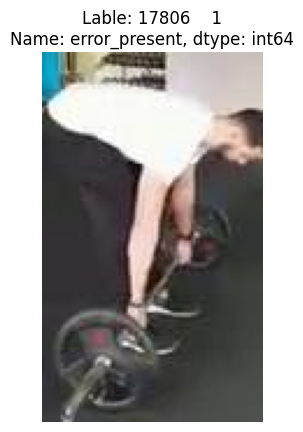

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\56069_1_2.jpg 1 / 1


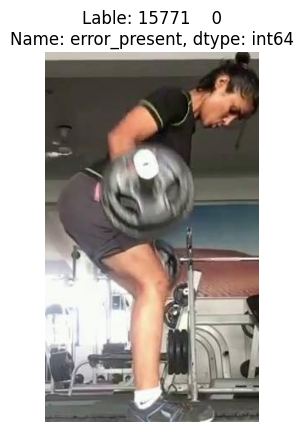

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\57498_4_26.jpg 0 / 1


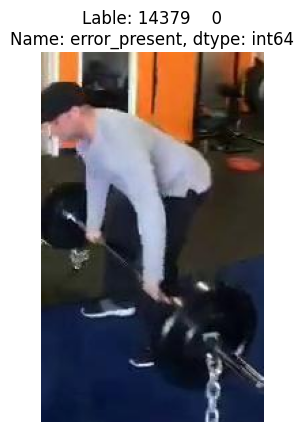

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\61761_3_27.jpg 0 / 1


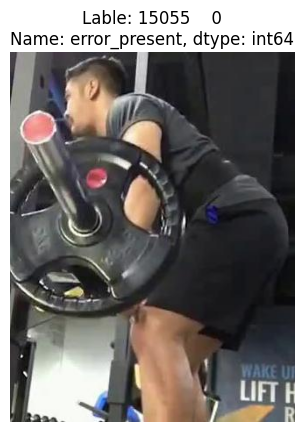

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\57841_3_0.jpg 0 / 1


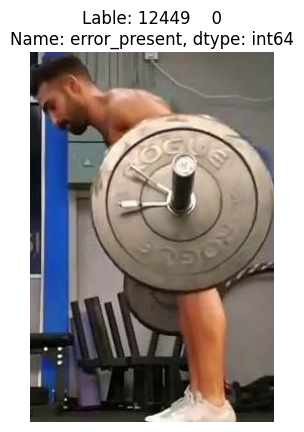

D:/My Work/MS/5th Sem Project/Dataset/Ftiness AQA/BarbellRow-20260203T232029Z-3-001/BarbellRow/Labeled_Dataset/barbellrow_images_raw/barbellrow_images_raw\60924_3_10.jpg 0 / 1


In [28]:
# doing a random visual sanity check

sample_vids = frame_df['frame_path'].drop_duplicates().sample(5)

for vid in sample_vids:
    img = cv2.imread(vid)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    subset = frame_df[frame_df['frame_path'] == vid]
    plt.imshow(img)
    plt.title(f"Lable: {subset['error_present']}")
    plt.axis('off')
    plt.show()

    print(vid, subset['error_present'].sum(), "/",len(subset))

In [29]:
frame_df

,frame_id,error_present,video_name,frame_path,exists
0,62149_4_20,0,62149_4,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
1,59188_4_55,0,59188_4,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
2,59791_6_21,0,59791_6,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
3,54896_10_5,0,54896_10,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
4,60070_7_10,1,60070_7,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
...,...,...,...,...,...
18616,58875_1_45,0,58875_1,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
18617,56226_1_47,0,56226_1,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
18618,60619_3_29,0,60619_3,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True
18619,58702_1_45,0,58702_1,D:/My Work/MS/5th Sem Project/Dataset/Ftiness ...,True


In [32]:
# Testing frame level binary classification only for barbell rows

# step 1 : cleaning the dataframe
df = frame_df.copy()

df = df[df["exists"] == True].reset_index(drop=True)
df["error_present"] = df["error_present"].astype(int)

print(df["error_present"].value_counts())
print(df["error_present"].value_counts(normalize = True))

error_present
0    14629
1     3992
Name: count, dtype: int64
error_present
0    0.785618
1    0.214382
Name: proportion, dtype: float64


In [35]:
# step 2 - creating test train split by videos (not by frames)
splitter = GroupShuffleSplit(
    n_splits = 1,
    test_size = 0.2,
    random_state = 42
)

train_idx, val_idx = next(
    splitter.split(df, groups=df["video_name"])
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop = True)

print("Train frames:", len(train_df))
print("Val Frames:", len(val_df))
print("Train videos:", train_df["video_name"].nunique())
print("Val videos:", val_df["video_name"].nunique())

Train frames: 14890
Val Frames: 3731
Train videos: 1502
Val videos: 376


In [ ]:
# step 3 : creating Dataset class

class FrameDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["frame_path"]
        label = float(row["error_present"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [ ]:
# step 4 : Vit for preprocessing

weights = ViT_B_16_Weights.IMAGENET1K_V1
tranform = weights.transforms()

In [ ]:
# step 5 : Data Loaders and Batching

BATCH_SIZE = 16

train_dataset = FrameDataset(train_df, transform=transform)
val_dataset = FrameDataset(val_df, transform = transform)

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers=2
)